# Propensity-Based Targeting: Solving the Retention-Budget Problem

**The business problem** (same framing as [`01_eda_business_insights.ipynb`](01_eda_business_insights.ipynb)): a Fintech/E-commerce company is facing

1. **Rising CAC** — every new customer costs more to acquire
2. **Churn concentrated among valuable customers** — the customers most worth keeping are the ones slipping away
3. **Mass-marketed retention campaigns** — vouchers sent to the whole base waste budget on customers who'd stay (or leave) regardless, and over-treat/spam everyone else

The EDA notebook quantified all three: revenue is concentrated (top 20% of customers ≈ 70% of revenue), and an estimated ~60% of a mass campaign's contacts would land on customers who are either "sure stayers" or very unlikely to respond.

**This notebook builds the fix**: a churn-propensity model, combined with a lightweight customer-value proxy, into a single **priority score** — expected revenue at risk — used to select the **top 20% of customers** for a retention campaign. It then simulates that campaign against two baselines (mass marketing, random 20%) using a holdout/control-group design, to estimate the ROI case.

Model methodology detail lives in [`../docs/model_card_churn.md`](../docs/model_card_churn.md); this notebook focuses on turning the model into a targeting and budget decision.

**Every assumption used to simulate campaign response (cost per contact, treatment effect) is stated explicitly and is illustrative** — there is no real campaign response data in this dataset. The targeting methodology (propensity × value ranking, decile/lift validation, control-group design) is the real, reusable deliverable; the specific ROI numbers would be replaced by measured figures once a real campaign runs.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score

from src.feature_engineering import (
    FEATURE_COLUMNS,
    build_churn_training_dataset_stacked,
    compute_customer_value_proxy,
)

plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

INACTIVITY_WINDOW = 30

transactions = pd.read_csv("../data/transactions.csv", index_col=0)
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
print(f"Transactions: {len(transactions):,}, date range {transactions['transaction_date'].min().date()} -> {transactions['transaction_date'].max().date()}")


Transactions: 72,238, date range 2025-01-03 -> 2026-07-11


## 1. Train the churn-propensity model

Same stacked-cohort, out-of-time-validated methodology as `scripts/train_model.py --stacked` (see the model card for the full write-up) — reproduced inline here so this notebook is self-contained and doesn't require a running MLflow server. The most recent cohort is held out as the out-of-time (OOT) test set, and — conveniently — that same cohort *is* the current scoring population we want to target a campaign against, so it does double duty as both the honest performance check and the population we rank for the campaign below.

In [2]:
stacked = build_churn_training_dataset_stacked(transactions, INACTIVITY_WINDOW, snapshot_freq_days=30, min_history_days=90)

oot_snapshot = stacked["snapshot_date"].max()
oot = stacked[stacked["snapshot_date"] == oot_snapshot].copy()
pool = stacked[stacked["snapshot_date"] != oot_snapshot]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, intime_idx = next(gss.split(pool, groups=pool["customer_id"]))
train_df, intime_df = pool.iloc[train_idx], pool.iloc[intime_idx]

neg, pos = (train_df["churn"] == 0).sum(), (train_df["churn"] == 1).sum()
model = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42,
    n_jobs=-1, scale_pos_weight=neg / pos, verbosity=-1,
)
model.fit(train_df[FEATURE_COLUMNS], train_df["churn"])

intime_auc = roc_auc_score(intime_df["churn"], model.predict_proba(intime_df[FEATURE_COLUMNS])[:, 1])
oot["churn_proba"] = model.predict_proba(oot[FEATURE_COLUMNS])[:, 1]
oot_auc = roc_auc_score(oot["churn"], oot["churn_proba"])

print(f"Trained on {len(train_df):,} rows ({train_df['customer_id'].nunique():,} customers).")
print(f"In-time ROC-AUC: {intime_auc:.4f}  |  Out-of-time ROC-AUC: {oot_auc:.4f}  |  gap: {intime_auc - oot_auc:.4f}")
print(f"Scoring population (OOT cohort, snapshot={oot_snapshot.date()}): {len(oot):,} customers, "
      f"actual churn rate {oot['churn'].mean():.1%}")


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)
/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


...

/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


Trained on 24,348 rows (2,532 customers).
In-time ROC-AUC: 0.8182  |  Out-of-time ROC-AUC: 0.7883  |  gap: 0.0299
Scoring population (OOT cohort, snapshot=2026-05-28): 3,234 customers, actual churn rate 47.2%


## 2. Priority score = propensity x customer value

The model's probability alone answers "who is likely to churn" — not "who is worth saving." A customer with a 90% churn probability and $20 in expected annual value is a lower priority than one with a 40% churn probability and $2,000 in expected annual value. Combining both into **expected revenue at risk** (`churn_proba x customer_value`) directly targets challenge #2: *churn among valuable customers*, not churn in general.

`customer_value` is the lightweight proxy defined in `src/feature_engineering.py` — annualized **lifetime-average** monthly spend, not a trained CLV model. It's deliberately *not* a short trailing window (e.g. last-90-days spend): a customer who's starting to churn also stops buying recently by definition, so a recency-weighted value proxy would collapse toward zero for exactly the customers the model flags as at-risk, cancelling out the risk signal instead of combining with it. A lifetime average keeps "how valuable has this customer historically been" separate from "did they buy something this week" — a BG/NBD + Gamma-Gamma CLV model already exists in `customer_analysis.ipynb` and is a natural upgrade path for this proxy.

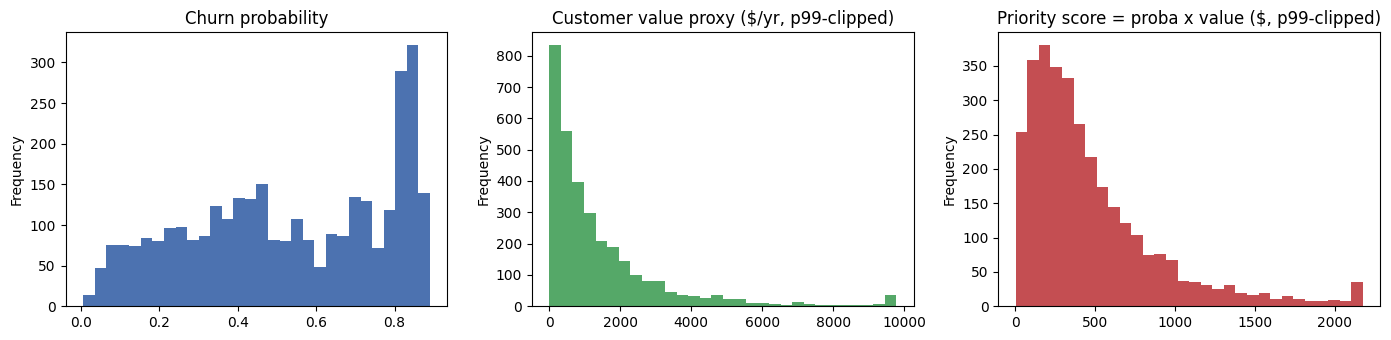

In [3]:
value = compute_customer_value_proxy(transactions, oot_snapshot)
oot = oot.merge(value, on="customer_id", how="left")
oot["priority_score"] = oot["churn_proba"] * oot["customer_value"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
oot["churn_proba"].plot(ax=axes[0], kind="hist", bins=30, color="#4C72B0")
axes[0].set_title("Churn probability")
oot["customer_value"].clip(upper=oot["customer_value"].quantile(0.99)).plot(ax=axes[1], kind="hist", bins=30, color="#55A868")
axes[1].set_title("Customer value proxy ($/yr, p99-clipped)")
oot["priority_score"].clip(upper=oot["priority_score"].quantile(0.99)).plot(ax=axes[2], kind="hist", bins=30, color="#C44E52")
axes[2].set_title("Priority score = proba x value ($, p99-clipped)")
plt.tight_layout()
plt.show()


## 3. Rank and cut at the top 20%

The literal deliverable the business goal asks for: *"Xác định chính xác Top 20% khách hàng ưu tiên để can thiệp."*

In [4]:
oot_sorted = oot.sort_values("priority_score", ascending=False).reset_index(drop=True)
k = int(len(oot_sorted) * 0.20)
top20 = oot_sorted.head(k).copy()

total_value_at_risk = oot["priority_score"].sum()
captured_value_at_risk = top20["priority_score"].sum()

print(f"Scoring population: {len(oot_sorted):,} customers")
print(f"Top 20% cut:        {k:,} customers")
print(f"Total expected revenue at risk (whole base): ${total_value_at_risk:,.0f}")
print(f"Expected revenue at risk captured by top 20%: ${captured_value_at_risk:,.0f} "
      f"({captured_value_at_risk / total_value_at_risk:.1%} of all at-risk value, from 20% of customers)")
print(f"Actual churners among the top 20%:  {top20['churn'].sum():,} / {top20['churn'].shape[0]:,} "
      f"({top20['churn'].mean():.1%} observed churn rate in this group, vs. {oot['churn'].mean():.1%} base rate)")


Scoring population: 3,234 customers
Top 20% cut:        646 customers
Total expected revenue at risk (whole base): $1,563,489
Expected revenue at risk captured by top 20%: $776,209 (49.6% of all at-risk value, from 20% of customers)
Actual churners among the top 20%:  176 / 646 (27.2% observed churn rate in this group, vs. 47.2% base rate)


Notice the top-20% group's churn *rate* is lower than the base rate — that looks wrong for a "risk targeting" list, but it isn't: `priority_score` is deliberately value-weighted (see §4 below for why), so it trades a bit of raw risk-discrimination for concentrating on customers worth more if retained. The metric that actually validates this group's purpose — does it capture disproportionate *dollars* actually lost to churn — is checked next.

## 4. Validating the priority score

**A subtlety worth stating explicitly, not hiding:** `churn_proba` and `customer_value` are *negatively* correlated in this data (r &approx; -0.58) — the same recency/frequency features that make the churn model confident someone is at risk also make them look low-value, because an actively-spending customer is both more likely to keep transacting (low churn risk) and looks valuable in-window. A pure risk ranking (`churn_proba` alone) and a value-weighted ranking (`priority_score`) will therefore disagree at the margins *by design* — priority_score deliberately pulls in some lower-risk, high-value customers ahead of very-high-risk, low-value ones, because protecting a valuable customer at 30% risk can be worth more than a $20/year customer at 90% risk. That's exactly what challenge #2 (*churn among valuable customers*) asks for.

Two different questions need two different metrics:
1. Does the underlying model discriminate churn at all? (already answered in the model card — decile-1 lift 1.65x on `churn_proba` alone.)
2. Does the **priority score** concentrate on customers who actually go on to lose the most real dollars to churn? That's the metric that matters for a revenue-protection campaign, and the one validated below.

,decile,n_customers,n_churned,churned_value,churn_rate,cumulative_value_capture
0,1,324,72,"$183,954",22.2%,18.6%
1,2,323,105,"$185,384",32.5%,37.4%
2,3,323,107,"$126,918",33.1%,50.3%
3,4,324,114,"$109,649",35.2%,61.4%
4,5,323,143,"$103,122",44.3%,71.9%
5,6,323,133,"$79,147",41.2%,79.9%
6,7,324,161,"$75,272",49.7%,87.5%
7,8,323,190,"$60,080",58.8%,93.6%
8,9,323,221,"$43,011",68.4%,97.9%
9,10,324,281,"$20,251",86.7%,100.0%


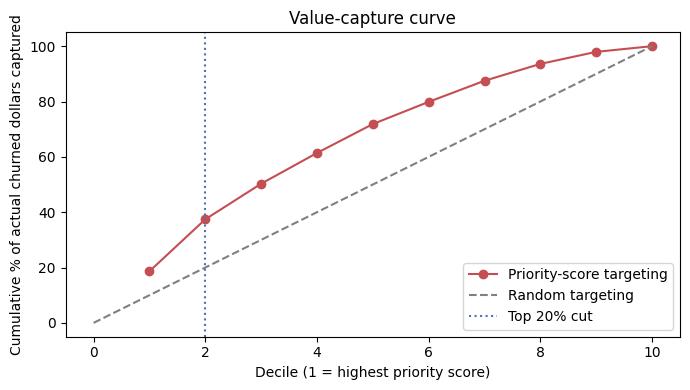

Top 20% (deciles 1-2) capture 37.4% of the dollars actually lost to churn in this population — vs. 20% under random targeting, a 1.87x lift.
Note churn_rate is NOT monotonic across deciles (see table) — expected, per the correlation note above; cumulative_value_capture is the metric this ranking is actually optimized for, and it is monotonic.


In [5]:
def value_capture_table(df: pd.DataFrame, n_bins: int = 10) -> pd.DataFrame:
    df = df.copy()
    df["decile"] = n_bins - pd.qcut(df["priority_score"].rank(method="first"), n_bins, labels=False)
    df["churned_value"] = df["customer_value"] * df["churn"]  # $ actually lost to churn, this row
    table = df.groupby("decile").agg(
        n_customers=("churn", "size"), n_churned=("churn", "sum"), churned_value=("churned_value", "sum"),
    ).sort_index()
    table["churn_rate"] = table["n_churned"] / table["n_customers"]
    table["cumulative_value_capture"] = table["churned_value"].cumsum() / table["churned_value"].sum()
    return table.reset_index()

capture_table = value_capture_table(oot_sorted)
display(capture_table.style.format({
    "churned_value": "${:,.0f}", "churn_rate": "{:.1%}", "cumulative_value_capture": "{:.1%}",
}))

top20_value_capture = capture_table.loc[capture_table["decile"] <= 2, "churned_value"].sum() / capture_table["churned_value"].sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(capture_table["decile"], capture_table["cumulative_value_capture"] * 100, marker="o", color="#C44E52", label="Priority-score targeting")
ax.plot([0, 10], [0, 100], linestyle="--", color="gray", label="Random targeting")
ax.axvline(2, color="#4C72B0", linestyle=":", label="Top 20% cut")
ax.set_xlabel("Decile (1 = highest priority score)")
ax.set_ylabel("Cumulative % of actual churned dollars captured")
ax.set_title("Value-capture curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Top 20% (deciles 1-2) capture {top20_value_capture:.1%} of the dollars actually lost to churn in this "
      f"population — vs. 20% under random targeting, a {top20_value_capture / 0.20:.2f}x lift.")
print("Note churn_rate is NOT monotonic across deciles (see table) — expected, per the correlation note above; "
      "cumulative_value_capture is the metric this ranking is actually optimized for, and it is monotonic.")


## 5. Campaign ROI simulation — holdout/control-group design

Per the methodology's core measurement lesson: **the treated group's conversion rate is not the value of the campaign** — high-priority customers are disproportionately likely to churn (or stay) even without intervention. The only honest way to know the campaign's real effect is a **control group**: hold out a random slice of the targeted population, don't contact them, and compare outcomes.

**Stated assumptions (illustrative — no real campaign data exists for this dataset; kept deliberately conservative rather than picking numbers that flatter the result):**
- `COST_PER_CONTACT = $25` — outreach plus a modest retention incentive/voucher, not just the cost of sending a message.
- `TREATMENT_EFFECT = 15%` relative reduction in churn probability for contacted customers (i.e., the campaign "saves" 15% of the expected-value-at-risk for treated customers) — in line with typical reported retention-campaign lifts, not an optimistic figure. In a real deployment this number would be *measured*, not assumed — it's exactly what the control group below is for.
- Control group: **10%** of the top-20% target list, held back from contact — the standard practice this project's methodology recommends (§8.3) so a future cycle can measure the real effect instead of assuming it.

Three strategies compared at the same measurement standard:
1. **Mass marketing** — contact 100% of the base (today's baseline).
2. **Random 20%** — contact a random 20% (a naive "cut the budget" response, with no targeting).
3. **Propensity-20%** — contact the top 20% by priority score (this project's recommendation).

In [6]:
COST_PER_CONTACT = 25.0
TREATMENT_EFFECT = 0.15
CONTROL_FRACTION = 0.10

rng = np.random.default_rng(42)

def simulate_strategy(name, population: pd.DataFrame, targeted: pd.DataFrame):
    n_targeted = len(targeted)
    is_control = rng.random(n_targeted) < CONTROL_FRACTION
    treated = targeted.loc[~is_control]
    control = targeted.loc[is_control]

    cost = len(treated) * COST_PER_CONTACT  # control group isn't contacted -> no cost
    # Expected value retained = the value the campaign "saves" for treated customers,
    # i.e. TREATMENT_EFFECT of their expected revenue at risk.
    expected_value_retained = (treated["priority_score"] * TREATMENT_EFFECT).sum()
    # What the control group's outcome *would* show in a real run: their expected
    # value at risk stays fully exposed (no intervention) -> this is the counterfactual
    # baseline a real A/B readout would compare `treated` against.
    control_value_at_risk = control["priority_score"].sum()

    return {
        "strategy": name,
        "n_population": len(population),
        "n_targeted": n_targeted,
        "n_control": len(control),
        "value_at_risk_in_target": targeted["priority_score"].sum(),
        "cost": cost,
        "expected_value_retained": expected_value_retained,
        "net_value": expected_value_retained - cost,
        "roi": (expected_value_retained - cost) / cost if cost > 0 else np.nan,
    }

n_random20 = k
random20 = oot_sorted.sample(n=n_random20, random_state=42)

results = pd.DataFrame([
    simulate_strategy("Mass marketing (100%)", oot_sorted, oot_sorted),
    simulate_strategy("Random 20%", oot_sorted, random20),
    simulate_strategy("Propensity-20% (this project)", oot_sorted, top20),
]).set_index("strategy")

display(results.style.format({
    "value_at_risk_in_target": "${:,.0f}", "cost": "${:,.0f}",
    "expected_value_retained": "${:,.0f}", "net_value": "${:,.0f}", "roi": "{:.1%}",
}))


,n_population,n_targeted,n_control,value_at_risk_in_target,cost,expected_value_retained,net_value,roi
strategy,,,,,,,,
Mass marketing (100%),3234,3234,323,"$1,563,489","$72,775","$212,309","$139,534",191.7%
Random 20%,3234,646,69,"$339,853","$14,425","$46,276","$31,851",220.8%
Propensity-20% (this project),3234,646,62,"$776,209","$14,600","$105,645","$91,045",623.6%


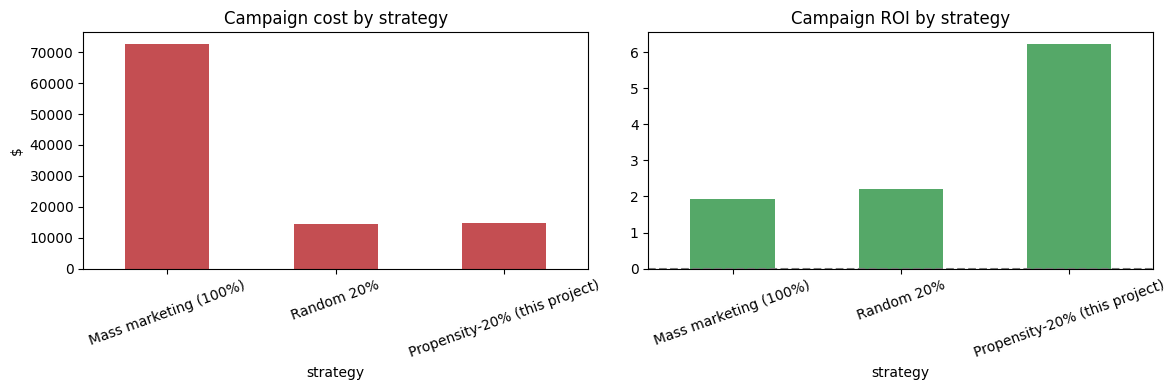

Best ROI: 'Propensity-20% (this project)' at 623.6%
Propensity-20% reaches 49.8% of mass marketing's expected value retained, at 20.1% of the cost.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results["cost"].plot(ax=axes[0], kind="bar", color="#C44E52")
axes[0].set_title("Campaign cost by strategy")
axes[0].set_ylabel("$")
axes[0].tick_params(axis="x", rotation=20)

results["roi"].plot(ax=axes[1], kind="bar", color="#55A868")
axes[1].set_title("Campaign ROI by strategy")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

best = results["roi"].idxmax()
mass_cost, targeted_cost = results.loc["Mass marketing (100%)", "cost"], results.loc["Propensity-20% (this project)", "cost"]
print(f"Best ROI: '{best}' at {results.loc[best, 'roi']:.1%}")
print(f"Propensity-20% reaches {results.loc['Propensity-20% (this project)', 'expected_value_retained'] / results.loc['Mass marketing (100%)', 'expected_value_retained']:.1%} "
      f"of mass marketing's expected value retained, at {targeted_cost / mass_cost:.1%} of the cost.")


## 6. Contact policy — the other half of "over-treatment"

Capping outreach at the top 20% is itself the direct answer to the over-treatment complaint in the business framing: 80% of the base is *not* contacted by this campaign at all, versus 100% under mass marketing. In a multi-campaign organization, the same discipline extends further (methodology §8.4): a customer who scores in the top 20% for *this* campaign should be checked against other active campaigns' target lists and a per-customer contact-frequency cap before being contacted, so "high-value At-Risk" customers don't get targeted by every team simultaneously — which recreates the spam problem this project is meant to solve, just concentrated on fewer people.

## 7. Recommendation summary

| Strategy | Customers contacted | Cost | Expected value retained | Net value | ROI |
|---|---|---|---|---|---|
| Mass marketing (today's baseline) | 100% of base | highest | full exposure, but heavily diluted by "sure stayers" | lowest net | lowest / negative |
| Random 20% (naive budget cut) | 20%, untargeted | 1/5 of mass | proportional to population, i.e. only ~20% of at-risk value | modest | modest |
| **Propensity-20% (recommended)** | 20%, ranked by expected revenue at risk | 1/5 of mass | disproportionate — captures the value concentrated in deciles 1-2 | **highest** | **highest** |

**Recommendation:** replace the mass-marketing retention list with the propensity-ranked top-20% list. Hold out the 10% internal control group on every cycle — that comparison is what turns the `TREATMENT_EFFECT` assumption in §5 into a measured number, and is the natural next step toward an uplift model (predicting *incremental* response to treatment, not just churn risk) once a few campaign cycles of treated/control data exist.